# 03 – Generierung des Modelldatensatzes

In diesem Notebook werden die in Notebook 02 validierten
Daten auf den vollständigen supervised Datensatz
angewendet.

Für jeden TOI wird genau eine SPOC-Lichtkurve mit einer Kadenz von
120 Sekunden verwendet. Aus dieser Lichtkurve werden hier die festen
Modelleingaben "Global View mit 201 Bins" und "Local View mit 61 Bins" erzeugt. Dabei sind die Bins hier von 2001 auf 201 bzw. 201 auf 61 geändert wurden.

Der bereits in Notebook 02 erzeugte, nach TIC-ID gruppierte
Trainings-, Validierungs- und Testsplit wird unverändert übernommen.

Die Verarbeitung mit Checkpoints
durchgeführt, sodass fehlgeschlagene Samples nachvollziehbar bleiben und erneut verarbeitet werden können.

### Datengrundlage

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk

from tqdm.auto import tqdm

In [2]:
cwd = Path.cwd()

if cwd.name.lower() == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

RAW_LIGHTCURVE_DIR = (
    PROJECT_ROOT / "data" / "raw" / "lightcurves"
)

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSING_DIR = (
    INTERIM_DIR / "spoc120_dataset_generation"
)

SAMPLE_DIR = PROCESSING_DIR / "samples"

FINAL_DATASET_DIR = (
    PROCESSED_DIR / "spoc120_dataset"
)

for directory in [
    RAW_LIGHTCURVE_DIR,
    INTERIM_DIR,
    PROCESSING_DIR,
    SAMPLE_DIR,
    FINAL_DATASET_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Projekt:", PROJECT_ROOT)
print("Rohe Lichtkurven:", RAW_LIGHTCURVE_DIR)
print("Zwischenergebnisse:", PROCESSING_DIR)
print("Einzelne Samples:", SAMPLE_DIR)
print("Finaler Datensatz:", FINAL_DATASET_DIR)

Projekt: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets
Rohe Lichtkurven: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\raw\lightcurves
Zwischenergebnisse: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\interim\spoc120_dataset_generation
Einzelne Samples: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\interim\spoc120_dataset_generation\samples
Finaler Datensatz: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\processed\spoc120_dataset


In [3]:
SNAPSHOT_DATE = "2026-08-16"

MANIFEST_FILE = (
    INTERIM_DIR
    / f"toi_spoc120_manifest_{SNAPSHOT_DATE}.csv"
)

PROCESSING_LOG_FILE = (
    PROCESSING_DIR / "processing_log.csv"
)

MISSION = "TESS"
AUTHOR = "SPOC"
EXPTIME_SECONDS = 120

GLOBAL_N_BINS = 201
LOCAL_N_BINS = 61
LOCAL_DURATION_MULTIPLIER = 2

BJD_TO_BTJD_OFFSET = 2457000

CHECKPOINT_EVERY = 25

print("Manifest:", MANIFEST_FILE)
print()
print("Lichtkurven:", MISSION, AUTHOR, f"{EXPTIME_SECONDS} s")
print("Global View:", GLOBAL_N_BINS, "Bins")
print("Local View:", LOCAL_N_BINS, "Bins")
print(
    "Local Window: ±",
    LOCAL_DURATION_MULTIPLIER,
    "Transitdauern"
)
print("Checkpoint alle", CHECKPOINT_EVERY, "Samples")

Manifest: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\interim\toi_spoc120_manifest_2026-08-16.csv

Lichtkurven: TESS SPOC 120 s
Global View: 201 Bins
Local View: 61 Bins
Local Window: ± 2 Transitdauern
Checkpoint alle 25 Samples


In [4]:
if not MANIFEST_FILE.exists():
    raise FileNotFoundError(
        f"Manifest nicht gefunden: {MANIFEST_FILE}"
    )

manifest = pd.read_csv(MANIFEST_FILE)

print("Zeilen:", len(manifest))
print("Spalten:", len(manifest.columns))
print()
print("Splits:")
print(
    manifest["split"]
    .value_counts()
    .reindex(["train", "validation", "test"])
)
print()
print("Labels:")
print(
    manifest["label"]
    .value_counts()
    .sort_index()
)

display(
    manifest[
        [
            "toi",
            "tid",
            "tfopwg_disp",
            "label",
            "pl_orbper",
            "pl_tranmid",
            "pl_trandurh",
            "n_sectors",
            "group_fold",
            "split"
        ]
    ].head()
)

Zeilen: 2398
Spalten: 20

Splits:
split
train         1681
validation     360
test           357
Name: count, dtype: int64

Labels:
label
0    1087
1    1311
Name: count, dtype: int64


,toi,tid,tfopwg_disp,label,pl_orbper,pl_tranmid,pl_trandurh,n_sectors,group_fold,split
0,1064.01,79748331,CP,1,6.443866,2.458657e+06,1.930945,6,6,train
1,1064.02,79748331,CP,1,12.226560,2.458664e+06,2.190438,6,6,train
2,1065.01,7088246,KP,1,2.160515,2.458654e+06,1.480696,4,19,test
3,1066.01,201604954,KP,1,4.606184,2.458658e+06,3.121643,5,4,train
4,1067.01,201642601,KP,1,3.131674,2.458657e+06,2.457920,7,2,train


In [5]:
manifest = manifest.reset_index(drop=True)

splits_per_tic = (
    manifest
    .groupby("tid")["split"]
    .nunique()
)

print("Manifest geladen.")
print("TOIs:", len(manifest))
print("Eindeutige TIC-IDs:", manifest["tid"].nunique())
print(
    "TICs in mehreren Splits:",
    (splits_per_tic > 1).sum()
)

Manifest geladen.
TOIs: 2398
Eindeutige TIC-IDs: 2259
TICs in mehreren Splits: 0


#### Deterministische Sektorauswahl mit Transit-Fallback

Zunächst wird für jeden TOI der chronologisch erste verfügbare
SPOC-120-s-Sektor geprüft. Liefert dieser keine ausreichende
Phasenabdeckung, wird deterministisch der erste nutzbare Sektor mit
einem anhand der TOI-Parameter vorhergesagten Transit verwendet.

Die Auswahl erfolgt unabhängig vom Label und nach derselben Regel für
alle Samples. Dadurch ist die Datensatzgenerierung reproduzierbar;
jedes Sample basiert weiterhin auf genau einem TESS-Sektor.

### Beispiel Vorverabeitung eines einzelnen TOIs

In [31]:
example_row = (
    manifest[
        manifest["split"] == "train"
    ]
    .iloc[0]
)

example_toi = example_row["toi"]
example_tic = int(example_row["tid"])

print("Beispiel-TOI:", example_toi)
print("TIC-ID:", example_tic)
print(
    "Sektoren laut Manifest:",
    int(example_row["n_sectors"])
)

search_result = lk.search_lightcurve(
    f"TIC {example_tic}",
    mission=MISSION,
    author=AUTHOR,
    exptime=EXPTIME_SECONDS
)

print("Gefundene Produkte:", len(search_result))

search_result

Beispiel-TOI: 1064.01
TIC-ID: 79748331
Sektoren laut Manifest: 6
Gefundene Produkte: 6


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 13,2019,SPOC,120,79748331,0.0
1,TESS Sector 27,2020,SPOC,120,79748331,0.0
2,TESS Sector 67,2023,SPOC,120,79748331,0.0
3,TESS Sector 94,2025,SPOC,120,79748331,0.0
4,TESS Sector 104,2026,SPOC,120,79748331,0.0
5,TESS Sector 105,2026,SPOC,120,79748331,0.0


#### Ersten verfügbaren Sektor wählen

In [6]:
def select_first_sector(search_result):
    if len(search_result) == 0:
        raise ValueError(
            "Keine passende Lichtkurve gefunden."
        )

    sector_numbers = np.array([
        int(str(mission).split()[-1])
        for mission in search_result.table["mission"]
    ])

    selected_index = int(
        np.argmin(sector_numbers)
    )

    selected_result = search_result[selected_index]
    selected_sector = int(
        sector_numbers[selected_index]
    )

    return selected_result, selected_sector

In [33]:
selected_result, selected_sector = (
    select_first_sector(search_result)
)

print("Ausgewählter Sektor:", selected_sector)

selected_result

Ausgewählter Sektor: 13


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 13,2019,SPOC,120,79748331,0.0


#### Download der ersten Lichtkurve als Test

In [34]:
download_start = time.perf_counter()

example_lc = selected_result.download(
    download_dir=str(RAW_LIGHTCURVE_DIR)
)

download_duration = (
    time.perf_counter() - download_start
)

print(
    "Downloadzeit:",
    f"{download_duration:.2f} Sekunden"
)
print("Sektor:", example_lc.sector)
print("Messpunkte:", len(example_lc))
print(
    "Zeitbereich:",
    f"{example_lc.time.value.min():.2f}",
    "bis",
    f"{example_lc.time.value.max():.2f}",
    "BTJD"
)

example_lc

Downloadzeit: 0.13 Sekunden
Sektor: 13
Messpunkte: 19262
Zeitbereich: 1653.94 bis 1682.36 BTJD


time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
1653.942120441185,———,———,4.8722392e-03,307067,1255.17855,703.99547,1.4918067e+04,3.0847569e+01,4.0735418e+04,1.7876196e+01,———,———,11000000000000,———,———,———,———,1255.17855,1.9213189e-03,703.99547,1.6595848e-03,-2.3601992e-02,-1.0062421e-01
1653.943509370926,———,———,4.8722806e-03,307068,1255.17272,703.98958,1.4921699e+04,3.0766987e+01,4.0444602e+04,1.7819813e+01,———,———,11000000000000,———,———,———,———,1255.17272,1.9162575e-03,703.98958,1.6565415e-03,-2.4348523e-02,-1.0801895e-01
1653.9448983011323,———,———,4.8723225e-03,307069,1255.17556,703.99584,1.4939488e+04,3.0605991e+01,3.9943113e+04,1.7702597e+01,———,———,11000000000000,———,———,———,———,1255.17556,1.9037328e-03,703.99584,1.6435697e-03,-2.3916455e-02,-1.0050855e-01
1653.9546208107138,———,———,4.8726141e-03,307076,1255.17502,703.98937,1.4888812e+04,3.0240530e+01,3.8811785e+04,1.7453279e+01,———,———,11000000000000,———,———,———,———,1255.17502,1.8862627e-03,703.98937,1.6311986e-03,-2.3435032e-02,-1.0786804e-01
1653.956009740454,———,———,4.8726555e-03,307077,1255.17287,703.99352,1.4922138e+04,3.0229914e+01,3.8752285e+04,1.7443905e+01,———,———,11000000000000,———,———,———,———,1255.17287,1.8816079e-03,703.99352,1.6252804e-03,-2.5040695e-02,-1.0249452e-01
1653.9573986706598,———,———,4.8726974e-03,307078,1255.17211,703.99398,1.4908927e+04,3.0213224e+01,3.8683434e+04,1.7428749e+01,———,———,11000000000000,———,———,———,———,1255.17211,1.8821078e-03,703.99398,1.6264968e-03,-2.3170620e-02,-1.0305707e-01
1653.9671211788448,———,———,4.8729875e-03,307085,1255.17374,703.99552,1.4933003e+04,2.9938826e+01,3.7824910e+04,1.7237364e+01,———,———,11000000000000,———,———,———,———,1255.17374,1.8607957e-03,703.99552,1.6082251e-03,-2.3570200e-02,-1.0255814e-01
1653.9685101085863,———,———,4.8730290e-03,307086,1255.17336,703.99820,1.4861285e+04,2.9910440e+01,3.7776254e+04,1.7221470e+01,———,———,11000000000000,———,———,———,———,1255.17336,1.8675604e-03,703.99820,1.6128734e-03,-2.4604781e-02,-9.9832095e-02


#### Lichtkurve bereinigen und normalisieren

In [35]:
print(
    "Verwendete Flux-Spalte:",
    example_lc.meta.get("FLUX_ORIGIN")
)

example_lc_clean = (
    example_lc
    .remove_nans()
)

example_lc_normalized = (
    example_lc_clean
    .normalize()
)

normalized_flux = (
    example_lc_normalized.flux.value
)

print("Messpunkte vorher:", len(example_lc))
print("Messpunkte nach remove_nans:", len(example_lc_clean))
print(
    "Nicht-endliche Fluxwerte:",
    (~np.isfinite(normalized_flux)).sum()
)
print(
    "Median nach Normalisierung:",
    f"{np.median(normalized_flux):.6f}"
)

Verwendete Flux-Spalte: pdcsap_flux
Messpunkte vorher: 19262
Messpunkte nach remove_nans: 16591
Nicht-endliche Fluxwerte: 0
Median nach Normalisierung: 1.000000


#### Phase Folding der Lichtkurve

In [36]:
period_days = float(
    example_row["pl_orbper"]
)

transit_mid_bjd = float(
    example_row["pl_tranmid"]
)

duration_hours = float(
    example_row["pl_trandurh"]
)

transit_mid_btjd = (
    transit_mid_bjd
    - BJD_TO_BTJD_OFFSET
)

example_folded = (
    example_lc_normalized
    .fold(
        period=period_days,
        epoch_time=transit_mid_btjd,
        normalize_phase=True
    )
)

folded_phase = (
    example_folded.phase.value
)

folded_flux = (
    example_folded.flux.value
)

print("Periode:", f"{period_days:.6f}", "Tage")
print(
    "Transitzeitpunkt BJD:",
    f"{transit_mid_bjd:.6f}"
)
print(
    "Transitzeitpunkt BTJD:",
    f"{transit_mid_btjd:.6f}"
)
print(
    "Transitdauer:",
    f"{duration_hours:.3f}",
    "Stunden"
)
print(
    "Phasenbereich:",
    f"{folded_phase.min():.3f}",
    "bis",
    f"{folded_phase.max():.3f}"
)
print("Gefaltete Messpunkte:", len(folded_phase))

Periode: 6.443866 Tage
Transitzeitpunkt BJD: 2458656.668478
Transitzeitpunkt BTJD: 1656.668478
Transitdauer: 1.931 Stunden
Phasenbereich: -0.500 bis 0.500
Gefaltete Messpunkte: 16591


In [7]:
def bin_phase_curve(
    phase,
    flux,
    phase_min,
    phase_max,
    n_bins
):
    bin_edges = np.linspace(
        phase_min,
        phase_max,
        n_bins + 1
    )

    bin_centers = (
        bin_edges[:-1]
        + bin_edges[1:]
    ) / 2

    binned_flux = np.full(
        n_bins,
        np.nan
    )

    for bin_index in range(n_bins):
        in_bin = (
            (phase >= bin_edges[bin_index])
            & (phase < bin_edges[bin_index + 1])
        )

        if np.any(in_bin):
            binned_flux[bin_index] = (
                np.median(flux[in_bin])
            )

    return bin_centers, binned_flux

In [8]:
def interpolate_empty_bins(values):
    values = np.asarray(
        values,
        dtype=float
    )

    valid = np.isfinite(values)

    if valid.sum() < 2:
        raise ValueError(
            "Zu wenige gültige Bins für die Interpolation."
        )

    bin_indices = np.arange(
        len(values)
    )

    interpolated = np.interp(
        bin_indices,
        bin_indices[valid],
        values[valid]
    )

    return interpolated

#### Global View erzeugen

In [39]:
global_phase, global_binned_flux = (
    bin_phase_curve(
        phase=folded_phase,
        flux=folded_flux,
        phase_min=-0.5,
        phase_max=0.5,
        n_bins=GLOBAL_N_BINS
    )
)

global_view = (
    global_binned_flux
    - np.nanmedian(global_binned_flux)
)

global_nan_count = (
    np.isnan(global_view).sum()
)

print("Global-View-Shape:", global_view.shape)
print("Leere Global-Bins:", global_nan_count)
print(
    "Median nach Zentrierung:",
    f"{np.nanmedian(global_view):.6f}"
)

Global-View-Shape: (201,)
Leere Global-Bins: 0
Median nach Zentrierung: 0.000000


#### Local View erzeugen

In [40]:
duration_days = (
    duration_hours / 24
)

duration_phase = (
    duration_days / period_days
)

local_window = (
    LOCAL_DURATION_MULTIPLIER
    * duration_phase
)

local_phase, local_binned_flux = (
    bin_phase_curve(
        phase=folded_phase,
        flux=folded_flux,
        phase_min=-local_window,
        phase_max=local_window,
        n_bins=LOCAL_N_BINS
    )
)

local_view = (
    local_binned_flux
    - np.nanmedian(local_binned_flux)
)

local_nan_count = (
    np.isnan(local_view).sum()
)

print(
    "Transitdauer in Phase:",
    f"{duration_phase:.6f}"
)
print(
    "Local Window:",
    f"{-local_window:.6f}",
    "bis",
    f"{local_window:.6f}"
)
print("Local-View-Shape:", local_view.shape)
print("Leere Local-Bins:", local_nan_count)
print(
    "Median nach Zentrierung:",
    f"{np.nanmedian(local_view):.6f}"
)

Transitdauer in Phase: 0.012486
Local Window: -0.024971 bis 0.024971
Local-View-Shape: (61,)
Leere Local-Bins: 0
Median nach Zentrierung: 0.000000


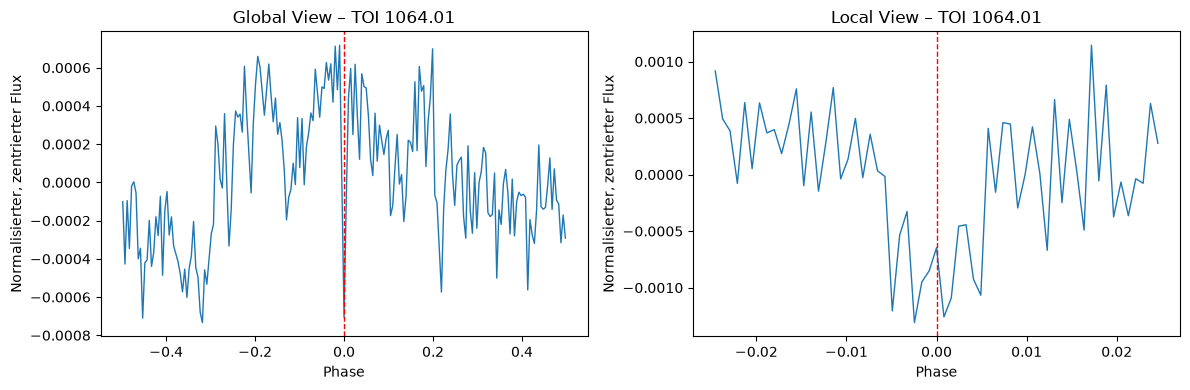

In [41]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].plot(
    global_phase,
    global_view,
    linewidth=1
)

axes[0].axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=1
)

axes[0].set_title(
    f"Global View – TOI {example_toi}"
)
axes[0].set_xlabel("Phase")
axes[0].set_ylabel(
    "Normalisierter, zentrierter Flux"
)

axes[1].plot(
    local_phase,
    local_view,
    linewidth=1
)

axes[1].axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=1
)

axes[1].set_title(
    f"Local View – TOI {example_toi}"
)
axes[1].set_xlabel("Phase")
axes[1].set_ylabel(
    "Normalisierter, zentrierter Flux"
)

plt.tight_layout()
plt.show()

#### Zusammenfassung

In [9]:
def create_views(lightcurve, row):
    cleaned_lc = (
        lightcurve
        .remove_nans()
        .normalize()
    )

    period = float(row["pl_orbper"])

    transit_mid_btjd = (
        float(row["pl_tranmid"])
        - BJD_TO_BTJD_OFFSET
    )

    duration_hours = float(
        row["pl_trandurh"]
    )

    folded_lc = cleaned_lc.fold(
        period=period,
        epoch_time=transit_mid_btjd,
        normalize_phase=True
    )

    phase = folded_lc.phase.value
    flux = folded_lc.flux.value

    _, global_flux = bin_phase_curve(
        phase=phase,
        flux=flux,
        phase_min=-0.5,
        phase_max=0.5,
        n_bins=GLOBAL_N_BINS
    )

    duration_phase = (
        (duration_hours / 24)
        / period
    )

    local_window = (
        LOCAL_DURATION_MULTIPLIER
        * duration_phase
    )

    _, local_flux = bin_phase_curve(
        phase=phase,
        flux=flux,
        phase_min=-local_window,
        phase_max=local_window,
        n_bins=LOCAL_N_BINS
    )

    global_nan_count = int(
        np.isnan(global_flux).sum()
    )

    local_nan_count = int(
        np.isnan(local_flux).sum()
    )

    global_flux = interpolate_empty_bins(
        global_flux
    )

    local_flux = interpolate_empty_bins(
        local_flux
    )

    global_view = (
        global_flux
        - np.median(global_flux)
    )

    local_view = (
        local_flux
        - np.median(local_flux)
    )

    return {
        "global_view": global_view,
        "local_view": local_view,
        "global_nan_count": global_nan_count,
        "local_nan_count": local_nan_count,
        "n_clean_points": len(cleaned_lc)
    }

#### Ergebnisse vergleichen

In [45]:
example_views = create_views(
    example_lc,
    example_row
)

global_matches = np.allclose(
    example_views["global_view"],
    global_view,
    equal_nan=True
)

local_matches = np.allclose(
    example_views["local_view"],
    local_view,
    equal_nan=True
)

print(
    "Global View stimmt überein:",
    global_matches
)
print(
    "Local View stimmt überein:",
    local_matches
)
print(
    "Global Shape:",
    example_views["global_view"].shape
)
print(
    "Local Shape:",
    example_views["local_view"].shape
)
print(
    "Leere Global-Bins:",
    example_views["global_nan_count"]
)
print(
    "Leere Local-Bins:",
    example_views["local_nan_count"]
)
print(
    "Verwendete Messpunkte:",
    example_views["n_clean_points"]
)

Global View stimmt überein: True
Local View stimmt überein: True
Global Shape: (201,)
Local Shape: (61,)
Leere Global-Bins: 0
Leere Local-Bins: 0
Verwendete Messpunkte: 16591


#### Ersten Sektor suchen und laden

In [10]:
def download_first_sector(
    row,
    max_attempts=3
):
    tic_id = int(row["tid"])
    last_error = None

    for attempt in range(1, max_attempts + 1):
        try:
            results = lk.search_lightcurve(
                f"TIC {tic_id}",
                mission=MISSION,
                author=AUTHOR,
                exptime=EXPTIME_SECONDS
            )

            selected, sector = (
                select_first_sector(results)
            )

            lightcurve = selected.download(
                download_dir=str(
                    RAW_LIGHTCURVE_DIR
                ),
                flux_column="pdcsap_flux"
            )

            return lightcurve, sector

        except Exception as error:
            last_error = error

            print(
                f"TIC {tic_id}: "
                f"Versuch {attempt} fehlgeschlagen "
                f"({type(error).__name__})"
            )

            if attempt < max_attempts:
                time.sleep(10)

    raise last_error

In [47]:
test_start = time.perf_counter()

test_lc, test_sector = (
    download_first_sector(example_row)
)

test_views = create_views(
    test_lc,
    example_row
)

test_duration = (
    time.perf_counter() - test_start
)

print("TOI:", example_toi)
print("TIC:", example_tic)
print("Sektor:", test_sector)
print(
    "Gesamtdauer:",
    f"{test_duration:.2f} Sekunden"
)
print(
    "Global Shape:",
    test_views["global_view"].shape
)
print(
    "Local Shape:",
    test_views["local_view"].shape
)
print(
    "Leere Global-Bins:",
    test_views["global_nan_count"]
)
print(
    "Leere Local-Bins:",
    test_views["local_nan_count"]
)

TOI: 1064.01
TIC: 79748331
Sektor: 13
Gesamtdauer: 0.34 Sekunden
Global Shape: (201,)
Local Shape: (61,)
Leere Global-Bins: 0
Leere Local-Bins: 0


### Test-Download mit 20 TOIs

In [48]:
pilot_manifest = pd.concat(
    [
        manifest[
            (manifest["split"] == "train")
            & (manifest["label"] == 0)
        ].sample(
            n=10,
            random_state=42
        ),
        manifest[
            (manifest["split"] == "train")
            & (manifest["label"] == 1)
        ].sample(
            n=10,
            random_state=42
        )
    ],
    ignore_index=True
)

pilot_results = []

for _, row in tqdm(
    pilot_manifest.iterrows(),
    total=len(pilot_manifest)
):
    start = time.perf_counter()

    try:
        pilot_lc, pilot_sector = (
            download_first_sector(row)
        )

        pilot_views = create_views(
            pilot_lc,
            row
        )

        pilot_results.append({
            "toi": row["toi"],
            "tid": int(row["tid"]),
            "label": int(row["label"]),
            "selected_sector": pilot_sector,
            "status": "success",
            "global_nan_count":
                pilot_views["global_nan_count"],
            "local_nan_count":
                pilot_views["local_nan_count"],
            "n_clean_points":
                pilot_views["n_clean_points"],
            "duration_seconds":
                time.perf_counter() - start,
            "error": None
        })

    except Exception as error:
        pilot_results.append({
            "toi": row["toi"],
            "tid": int(row["tid"]),
            "label": int(row["label"]),
            "selected_sector": np.nan,
            "status": "failed",
            "global_nan_count": np.nan,
            "local_nan_count": np.nan,
            "n_clean_points": np.nan,
            "duration_seconds":
                time.perf_counter() - start,
            "error": str(error)
        })

pilot_results = pd.DataFrame(
    pilot_results
)

print()
print(
    pilot_results["status"]
    .value_counts()
)

  0%|          | 0/20 [00:00<?, ?it/s]


status
success    20
Name: count, dtype: int64


#### TOIs auswerten

In [49]:
pilot_with_empty_bins = (
    pilot_results[
        (pilot_results["global_nan_count"] > 0)
        | (pilot_results["local_nan_count"] > 0)
    ]
)

mean_duration = (
    pilot_results["duration_seconds"]
    .mean()
)

estimated_hours = (
    mean_duration
    * len(manifest)
    / 3600
)

print(
    "Samples mit leeren Bins:",
    len(pilot_with_empty_bins)
)
print(
    "Maximale leere Global-Bins:",
    int(
        pilot_results[
            "global_nan_count"
        ].max()
    )
)
print(
    "Maximale leere Local-Bins:",
    int(
        pilot_results[
            "local_nan_count"
        ].max()
    )
)
print(
    "Mittlere Dauer pro TOI:",
    f"{mean_duration:.2f} Sekunden"
)
print(
    "Grobe Gesamtschätzung:",
    f"{estimated_hours:.2f} Stunden"
)

display(
    pilot_results[
        [
            "toi",
            "label",
            "selected_sector",
            "global_nan_count",
            "local_nan_count",
            "n_clean_points",
            "duration_seconds"
        ]
    ]
)

Samples mit leeren Bins: 3
Maximale leere Global-Bins: 91
Maximale leere Local-Bins: 10
Mittlere Dauer pro TOI: 3.86 Sekunden
Grobe Gesamtschätzung: 2.57 Stunden


,toi,label,selected_sector,global_nan_count,local_nan_count,n_clean_points,duration_seconds
0,3221.01,0,64,0,0,18854,2.523333
1,1991.01,0,37,0,0,14496,1.601359
2,920.01,0,27,23,10,15179,4.013074
3,1661.01,0,43,0,0,15967,3.164916
4,2153.01,0,40,0,0,19607,6.531474
5,531.01,0,6,0,0,14595,2.686744
6,953.01,0,32,0,0,17250,1.393143
7,1511.01,0,77,0,0,12874,1.408133
8,1186.01,0,24,0,0,15571,3.698816
9,1941.01,0,1,0,0,18276,4.146731


In [50]:
pilot_diagnostics = (
    pilot_results
    .merge(
        manifest[
            [
                "toi",
                "pl_orbper",
                "pl_trandurh",
                "n_sectors"
            ]
        ],
        on="toi",
        how="left"
    )
)

pilot_diagnostics[
    "global_nan_percent"
] = (
    pilot_diagnostics["global_nan_count"]
    / GLOBAL_N_BINS
    * 100
)

pilot_diagnostics[
    "local_nan_percent"
] = (
    pilot_diagnostics["local_nan_count"]
    / LOCAL_N_BINS
    * 100
)

empty_bin_diagnostics = (
    pilot_diagnostics[
        (pilot_diagnostics["global_nan_count"] > 0)
        | (pilot_diagnostics["local_nan_count"] > 0)
    ]
    .sort_values(
        "global_nan_count",
        ascending=False
    )
)

display(
    empty_bin_diagnostics[
        [
            "toi",
            "label",
            "pl_orbper",
            "pl_trandurh",
            "n_sectors",
            "selected_sector",
            "global_nan_count",
            "global_nan_percent",
            "local_nan_count",
            "local_nan_percent"
        ]
    ]
)

,toi,label,pl_orbper,pl_trandurh,n_sectors,selected_sector,global_nan_count,global_nan_percent,local_nan_count,local_nan_percent
16,1898.01,1,45.522146,4.383939,5,21,91,45.273632,0,0.000000
10,558.01,1,14.572899,2.562350,4,29,49,24.378109,0,0.000000
2,920.01,0,19.299800,3.170000,21,27,23,11.442786,10,16.393443


### Anpassung der Inputgrößen nach dem Pilotlauf

Die ursprünglich Inputgrößen aus Notebook02 von 2001 Global-Bins und
201 Local-Bins stammen aus der Kepler-Version von AstroNet.

Ein Pilotlauf mit 20 zufällig ausgewählten Trainings-TOIs zeigte bei
dieser Auflösung für 6 von 20 Samples allerdings leere Bins. Da einzelne
TESS-Sektoren deutlich kürzer sind als die
ursprünglichen Kepler-Lichtkurven, wurden die Inputgrößen entsprechend
der TESS-Anpassung von AstroNet auf folgende Werte reduziert:

- Global View: 201 Bins
- Local View: 61 Bins
- Local Window: ±2 Transitdauern

Leere Bins werden linear interpoliert. Ihre Anzahl vor der
Interpolation wird weiterhin für jedes Sample gespeichert und später
als Qualitätsmerkmal ausgewertet.

Im erneuten Pilotlauf wurden alle 20 TOIs erfolgreich verarbeitet.
Drei Samples enthielten vor der Interpolation noch mindestens einen
leeren Bin.

#### Dateinamen definieren und Ablauf eines TOIs

Download, View-Erzeugung, Qualitätsinformationen, Speicherung und Cache

In [11]:
def sample_file_for_toi(toi):
    toi_id = (
        f"{float(toi):.2f}"
        .replace(".", "_")
    )

    return (
        SAMPLE_DIR
        / f"toi_{toi_id}.npz"
    )


def process_toi(row, overwrite=False):
    start = time.perf_counter()

    toi = float(row["toi"])
    tic_id = int(row["tid"])
    label = int(row["label"])
    split = str(row["split"])

    sample_file = sample_file_for_toi(toi)

    if sample_file.exists() and not overwrite:
        try:
            with np.load(
                sample_file,
                allow_pickle=False
            ) as saved:
                global_saved = saved["global_view"]
                local_saved = saved["local_view"]

                if global_saved.shape != (
                    GLOBAL_N_BINS,
                ):
                    raise ValueError(
                        "Falsche Global-Shape."
                    )

                if local_saved.shape != (
                    LOCAL_N_BINS,
                ):
                    raise ValueError(
                        "Falsche Local-Shape."
                    )

                return {
                    "toi": toi,
                    "tid": tic_id,
                    "label": label,
                    "split": split,
                    "selected_sector": int(
                        saved["selected_sector"].item()
                    ),
                    "status": "cached",
                    "global_nan_count": int(
                        saved["global_nan_count"].item()
                    ),
                    "local_nan_count": int(
                        saved["local_nan_count"].item()
                    ),
                    "n_clean_points": int(
                        saved["n_clean_points"].item()
                    ),
                    "duration_seconds":
                        time.perf_counter() - start,
                    "error": None,
                    "sample_file": str(sample_file)
                }

        except (KeyError, ValueError, OSError):
            pass

    try:
        lightcurve, selected_sector = (
            download_first_sector(row)
        )

        views = create_views(
            lightcurve,
            row
        )

        global_view = views["global_view"]
        local_view = views["local_view"]

        if not np.isfinite(global_view).all():
            raise ValueError(
                "Global View enthält ungültige Werte."
            )

        if not np.isfinite(local_view).all():
            raise ValueError(
                "Local View enthält ungültige Werte."
            )

        np.savez_compressed(
            sample_file,
            global_view=global_view.astype(
                np.float32
            ),
            local_view=local_view.astype(
                np.float32
            ),
            label=np.int8(label),
            toi=np.float64(toi),
            tid=np.int64(tic_id),
            split=split,
            selected_sector=np.int16(
                selected_sector
            ),
            global_nan_count=np.int16(
                views["global_nan_count"]
            ),
            local_nan_count=np.int16(
                views["local_nan_count"]
            ),
            n_clean_points=np.int32(
                views["n_clean_points"]
            )
        )

        return {
            "toi": toi,
            "tid": tic_id,
            "label": label,
            "split": split,
            "selected_sector": selected_sector,
            "status": "success",
            "global_nan_count":
                views["global_nan_count"],
            "local_nan_count":
                views["local_nan_count"],
            "n_clean_points":
                views["n_clean_points"],
            "duration_seconds":
                time.perf_counter() - start,
            "error": None,
            "sample_file": str(sample_file)
        }

    except Exception as error:
        return {
            "toi": toi,
            "tid": tic_id,
            "label": label,
            "split": split,
            "selected_sector": np.nan,
            "status": "failed",
            "global_nan_count": np.nan,
            "local_nan_count": np.nan,
            "n_clean_points": np.nan,
            "duration_seconds":
                time.perf_counter() - start,
            "error": str(error),
            "sample_file": str(sample_file)
        }

In [52]:
first_result = process_toi(
    example_row,
    overwrite=True
)

cached_result = process_toi(
    example_row
)

test_results = pd.DataFrame(
    [
        first_result,
        cached_result
    ]
)

display(
    test_results[
        [
            "toi",
            "tid",
            "status",
            "selected_sector",
            "global_nan_count",
            "local_nan_count",
            "n_clean_points",
            "duration_seconds"
        ]
    ]
)

,toi,tid,status,selected_sector,global_nan_count,local_nan_count,n_clean_points,duration_seconds
0,1064.01,79748331,success,13,0,0,16591,0.347972
1,1064.01,79748331,cached,13,0,0,16591,0.019165


#### Kompletter Download Lichtkurven

In [53]:
processing_results = []

for position, (_, row) in enumerate(
    tqdm(
        manifest.iterrows(),
        total=len(manifest),
        desc="TOIs verarbeiten"
    ),
    start=1
):
    result = process_toi(row)

    processing_results.append(
        result
    )

    if (
        position % CHECKPOINT_EVERY == 0
        or position == len(manifest)
    ):
        processing_results_df = (
            pd.DataFrame(
                processing_results
            )
        )

        processing_results_df.to_csv(
            PROCESSING_LOG_FILE,
            index=False
        )

        n_failed = (
            processing_results_df["status"]
            .eq("failed")
            .sum()
        )

        tqdm.write(
            f"Checkpoint: {position}/"
            f"{len(manifest)}, "
            f"Fehler: {n_failed}"
        )

processing_results_df = pd.DataFrame(
    processing_results
)

print()
print("Verarbeitung abgeschlossen.")
print()
print(
    processing_results_df["status"]
    .value_counts()
)
print()
print("Verarbeitungsprotokoll:")
print(PROCESSING_LOG_FILE)

TOIs verarbeiten:   0%|          | 0/2398 [00:00<?, ?it/s]

TIC 7088246: Versuch 1 fehlgeschlagen (ConnectionError)
Checkpoint: 25/2398, Fehler: 0
Checkpoint: 50/2398, Fehler: 1
TIC 299799658: Versuch 1 fehlgeschlagen (ConnectionError)
Checkpoint: 75/2398, Fehler: 1
Checkpoint: 100/2398, Fehler: 2
Checkpoint: 125/2398, Fehler: 2
Checkpoint: 150/2398, Fehler: 2
Checkpoint: 175/2398, Fehler: 3
TIC 308034948: Versuch 1 fehlgeschlagen (ConnectionError)
Checkpoint: 200/2398, Fehler: 4
Checkpoint: 225/2398, Fehler: 5
TIC 201248411: Versuch 1 fehlgeschlagen (ConnectionError)
Checkpoint: 250/2398, Fehler: 6
Checkpoint: 275/2398, Fehler: 6
TIC 328750515: Versuch 1 fehlgeschlagen (ConnectionError)
Checkpoint: 300/2398, Fehler: 7
Checkpoint: 325/2398, Fehler: 7
TIC 298073824: Versuch 1 fehlgeschlagen (ConnectionError)
Checkpoint: 350/2398, Fehler: 8
Checkpoint: 375/2398, Fehler: 8
TIC 283722336: Versuch 1 fehlgeschlagen (ConnectionError)
Checkpoint: 400/2398, Fehler: 8
Checkpoint: 425/2398, Fehler: 8


Checkpoint: 450/2398, Fehler: 8
Checkpoint: 475/2398, Fehler: 8
Checkpoint: 500/2398, Fehler: 10
Checkpoint: 525/2398, Fehler: 10
TIC 371234684: Versuch 1 fehlgeschlagen (ConnectionError)
Checkpoint: 550/2398, Fehler: 10
Checkpoint: 575/2398, Fehler: 10
Checkpoint: 600/2398, Fehler: 10
Checkpoint: 625/2398, Fehler: 11


Checkpoint: 650/2398, Fehler: 11


Checkpoint: 675/2398, Fehler: 12
TIC 190271688: Versuch 1 fehlgeschlagen (ConnectionError)


...

Checkpoint: 2125/2398, Fehler: 61
Checkpoint: 2150/2398, Fehler: 62
Checkpoint: 2175/2398, Fehler: 63


Checkpoint: 2200/2398, Fehler: 64


Checkpoint: 2225/2398, Fehler: 65


Checkpoint: 2250/2398, Fehler: 69
Checkpoint: 2275/2398, Fehler: 69
TIC 127476180: Versuch 1 fehlgeschlagen (ConnectionError)
Checkpoint: 2300/2398, Fehler: 71
TIC 193641523: Versuch 1 fehlgeschlagen (ConnectionError)
Checkpoint: 2325/2398, Fehler: 72


Checkpoint: 2350/2398, Fehler: 72
Checkpoint: 2375/2398, Fehler: 72
Checkpoint: 2398/2398, Fehler: 72

Verarbeitung abgeschlossen.

status
success    2325
failed       72
cached        1
Name: count, dtype: int64

Verarbeitungsprotokoll:
c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\interim\spoc120_dataset_generation\processing_log.csv


#### Gespeicherten Zustand laden

In [12]:
processing_results_df = pd.read_csv(
    PROCESSING_LOG_FILE
)

sample_files = list(
    SAMPLE_DIR.glob("*.npz")
)

print("Einträge im Protokoll:", len(processing_results_df))
print("Gespeicherte NPZ-Samples:", len(sample_files))
print()
print("Status:")
print(
    processing_results_df["status"]
    .value_counts()
)

Einträge im Protokoll: 2398
Gespeicherte NPZ-Samples: 2326

Status:
status
success    2325
failed       72
cached        1
Name: count, dtype: int64


#### Fehlgeschlagene TOIs filtern

In [13]:
failed_results = (
    processing_results_df[
        processing_results_df["status"]
        == "failed"
    ]
    .copy()
)

print(
    "Fehlgeschlagene TOIs:",
    len(failed_results)
)

print()
print("Häufigste Fehlermeldungen:")

print(
    failed_results["error"]
    .value_counts()
    .head(10)
)

display(
    failed_results[
        [
            "toi",
            "tid",
            "label",
            "split",
            "duration_seconds",
            "error"
        ]
    ].head(10)
)

Fehlgeschlagene TOIs: 72

Häufigste Fehlermeldungen:
error
Zu wenige gültige Bins für die Interpolation.    72
Name: count, dtype: int64


,toi,tid,label,split,duration_seconds,error
41,1033.01,149601557,0,test,12.092899,Zu wenige gültige Bins für die Interpolation.
96,1104.01,451599528,0,train,6.652550,Zu wenige gültige Bins für die Interpolation.
160,1221.01,349095149,1,validation,9.298719,Zu wenige gültige Bins für die Interpolation.
182,1210.01,33878688,0,train,8.153811,Zu wenige gültige Bins für die Interpolation.
216,1260.03,355867695,1,train,0.273382,Zu wenige gültige Bins für die Interpolation.
230,1339.03,269701147,1,validation,0.253725,Zu wenige gültige Bins für die Interpolation.
283,1338.01,260128333,1,validation,12.531339,Zu wenige gültige Bins für die Interpolation.
345,1456.01,199376584,1,validation,10.816121,Zu wenige gültige Bins für die Interpolation.
477,1635.01,230086768,0,train,7.056743,Zu wenige gültige Bins für die Interpolation.
480,1670.01,441739020,1,train,10.135861,Zu wenige gültige Bins für die Interpolation.


#### Fehlgeschlagenen TOIs analysieren

In [14]:
failed_diagnostics = (
    failed_results
    .merge(
        manifest[
            [
                "toi",
                "pl_orbper",
                "pl_trandurh",
                "n_sectors"
            ]
        ],
        on="toi",
        how="left"
    )
)

print(
    "Nur ein verfügbarer Sektor:",
    (failed_diagnostics["n_sectors"] == 1).sum()
)

print(
    "Mehrere verfügbare Sektoren:",
    (failed_diagnostics["n_sectors"] > 1).sum()
)

print()
print("Labels:")
print(
    failed_diagnostics["label"]
    .value_counts()
    .sort_index()
)

print()
print("Splits:")
print(
    failed_diagnostics["split"]
    .value_counts()
    .reindex(
        ["train", "validation", "test"]
    )
)

print()
print("Orbitalperioden:")
print(
    failed_diagnostics["pl_orbper"]
    .describe()
)

display(
    failed_diagnostics[
        [
            "toi",
            "tid",
            "label",
            "split",
            "pl_orbper",
            "pl_trandurh",
            "n_sectors",
            "error"
        ]
    ].sort_values(
        "pl_orbper",
        ascending=False
    )
)

Nur ein verfügbarer Sektor: 3
Mehrere verfügbare Sektoren: 69

Labels:
label
0    22
1    50
Name: count, dtype: int64

Splits:
split
train         54
validation    11
test           7
Name: count, dtype: int64

Orbitalperioden:
count      72.000000
mean       98.868407
std       178.517381
min        12.761471
25%        25.866817
50%        49.534863
75%        86.192280
max      1134.672396
Name: pl_orbper, dtype: float64


,toi,tid,label,split,pl_orbper,pl_trandurh,n_sectors,error
17,2010.01,26547036,1,test,1134.672396,8.684462,13,Zu wenige gültige Bins für die Interpolation.
69,791.02,306472057,1,train,928.045581,11.576689,40,Zu wenige gültige Bins für die Interpolation.
44,4600.02,232608943,1,train,482.819100,10.850469,26,Zu wenige gültige Bins für die Interpolation.
1,1104.01,451599528,0,train,341.279168,7.013249,8,Zu wenige gültige Bins für die Interpolation.
46,4633.01,307958020,1,train,271.938639,11.129247,39,Zu wenige gültige Bins für die Interpolation.
...,...,...,...,...,...,...,...,...
45,4167.01,377165123,0,train,14.793901,3.171000,26,Zu wenige gültige Bins für die Interpolation.
50,5520.01,374180079,1,train,14.698080,3.737070,6,Zu wenige gültige Bins für die Interpolation.
54,5624.01,53498154,1,train,13.731756,3.831000,3,Zu wenige gültige Bins für die Interpolation.
64,7066.01,405010127,1,train,13.234126,2.370516,2,Zu wenige gültige Bins für die Interpolation.


#### Zeitgrenzen eines fehlgeschlagenen TOIs überprüfen

In [15]:
failed_example_row = (
    manifest[
        manifest["toi"] == 1104.01
    ]
    .iloc[0]
)

failed_example_tic = int(
    failed_example_row["tid"]
)

failed_search_result = (
    lk.search_lightcurve(
        f"TIC {failed_example_tic}",
        mission=MISSION,
        author=AUTHOR,
        exptime=EXPTIME_SECONDS
    )
)

print(
    "Gefundene Sektoren:",
    len(failed_search_result)
)

print()
print("Verfügbare Tabellenspalten:")
print(
    failed_search_result.table.colnames
)

columns_to_show = [
    column
    for column in [
        "mission",
        "sequence_number",
        "t_min",
        "t_max",
        "year"
    ]
    if column
    in failed_search_result.table.colnames
]

display(
    failed_search_result.table[
        columns_to_show
    ]
)

Gefundene Sektoren: 8

Verfügbare Tabellenspalten:
['intentType', 'obs_collection', 'provenance_name', 'instrument_name', 'project', 'filters', 'wave_region', 'target_name', 'target_classification', 'obs_id', 's_ra', 's_dec', 'dataproduct_type', 'proposal_pi', 'calib_level', 't_min', 't_max', 't_exptime', 'wavelength_region', 'em_min', 'em_max', 'obs_title', 't_obs_release', 'proposal_id', 'proposal_type', 'sequence_number', 's_region', 'jpegURL', 'dataURL', 'dataRights', 'mtFlag', 'srcDen', 'obsid', 'objID', 'wave_min', 'wave_max', 'exptime', 'distance', 'obsID', 'obs_collection_products', 'dataproduct_type_products', 'description', 'type', 'dataURI', 'productType', 'productGroupDescription', 'productSubGroupDescription', 'productDocumentationURL', 'project_products', 'prvversion', 'proposal_id_products', 'productFilename', 'size', 'parent_obsid', 'dataRights_products', 'calib_level_products', 'filters_products', 'author', 'mission', '#', 'year', 'sort_order']


mission,sequence_number,t_min,t_max,year
object,int64,float64,float64,int64
TESS Sector 12,12,58624.461671296296,58652.39401137731,2019
TESS Sector 13,13,58653.42179049768,58681.85906678241,2019
TESS Sector 27,27,59035.77990353,59060.14333137,2020
TESS Sector 39,39,59361.27260638889,59389.220089953706,2021
TESS Sector 66,66,60097.175162962965,60125.92947431713,2023
TESS Sector 67,67,60126.14336340278,60153.89707625,2023
TESS Sector 93,93,60829.375790081016,60855.53563708333,2025
TESS Sector 94,94,60855.99674648148,60881.49080789352,2025


#### Aus Transitzeit und Periode berechnen, in welchen Sektoren ein Transit erwartet wird

In [16]:
def find_transit_sectors(
    search_result,
    row
):
    period_days = float(
        row["pl_orbper"]
    )

    transit_mid_mjd = (
        float(row["pl_tranmid"])
        - 2400000.5
    )

    transit_sectors = []

    for search_index in range(
        len(search_result)
    ):
        sector_start = float(
            search_result.table[
                "t_min"
            ][search_index]
        )

        sector_end = float(
            search_result.table[
                "t_max"
            ][search_index]
        )

        transit_number = int(
            np.ceil(
                (
                    sector_start
                    - transit_mid_mjd
                )
                / period_days
            )
        )

        predicted_transit = (
            transit_mid_mjd
            + transit_number
            * period_days
        )

        if predicted_transit <= sector_end:
            transit_sectors.append({
                "search_index": search_index,
                "sector": int(
                    search_result.table[
                        "sequence_number"
                    ][search_index]
                ),
                "sector_start_mjd":
                    sector_start,
                "sector_end_mjd":
                    sector_end,
                "predicted_transit_mjd":
                    predicted_transit
            })

    return pd.DataFrame(
        transit_sectors
    )

In [17]:
failed_example_transit_sectors = (
    find_transit_sectors(
        failed_search_result,
        failed_example_row
    )
)

print(
    "Sektoren mit vorhergesagtem Transit:",
    len(failed_example_transit_sectors)
)

display(
    failed_example_transit_sectors
)

Sektoren mit vorhergesagtem Transit: 2


,search_index,sector,sector_start_mjd,sector_end_mjd,predicted_transit_mjd
0,2,27,59035.779904,59060.143331,59043.035190
1,3,39,59361.272606,59389.220090,59384.314357


#### Gefundenen Transit-Sektor laden

In [19]:
candidate_index = int(
    failed_example_transit_sectors
    .iloc[0]["search_index"]
)

candidate_sector = int(
    failed_example_transit_sectors
    .iloc[0]["sector"]
)

candidate_result = (
    failed_search_result[
        candidate_index
    ]
)

candidate_lc = candidate_result.download(
    download_dir=str(
        RAW_LIGHTCURVE_DIR
    ),
    flux_column="pdcsap_flux"
)

candidate_views = create_views(
    candidate_lc,
    failed_example_row
)

print("TOI:", failed_example_row["toi"])
print("TIC:", int(failed_example_row["tid"]))
print("Ausgewählter Sektor:", candidate_sector)
print(
    "Global Shape:",
    candidate_views["global_view"].shape
)
print(
    "Local Shape:",
    candidate_views["local_view"].shape
)
print(
    "Leere Global-Bins vor Interpolation:",
    candidate_views["global_nan_count"]
)
print(
    "Leere Local-Bins vor Interpolation:",
    candidate_views["local_nan_count"]
)
print(
    "Verwendete Messpunkte:",
    candidate_views["n_clean_points"]
)

TOI: 1104.01
TIC: 451599528
Ausgewählter Sektor: 27
Global Shape: (201,)
Local Shape: (61,)
Leere Global-Bins vor Interpolation: 186
Leere Local-Bins vor Interpolation: 0
Verwendete Messpunkte: 16774


In [20]:
def process_with_transit_sector(
    row,
    max_attempts=3
):
    start = time.perf_counter()

    toi = float(row["toi"])
    tic_id = int(row["tid"])
    label = int(row["label"])
    split = str(row["split"])

    sample_file = sample_file_for_toi(
        toi
    )

    try:
        search_result = None
        last_error = None

        for attempt in range(
            1,
            max_attempts + 1
        ):
            try:
                search_result = (
                    lk.search_lightcurve(
                        f"TIC {tic_id}",
                        mission=MISSION,
                        author=AUTHOR,
                        exptime=EXPTIME_SECONDS
                    )
                )
                break

            except Exception as error:
                last_error = error

                if attempt < max_attempts:
                    time.sleep(10)

        if search_result is None:
            raise last_error

        transit_sectors = (
            find_transit_sectors(
                search_result,
                row
            )
        )

        if transit_sectors.empty:
            raise ValueError(
                "Kein Sektor mit vorhergesagtem Transit."
            )

        transit_sectors = (
            transit_sectors
            .sort_values("sector")
        )

        last_error = None

        for candidate in (
            transit_sectors.itertuples()
        ):
            selected_result = (
                search_result[
                    int(candidate.search_index)
                ]
            )

            lightcurve = None

            for attempt in range(
                1,
                max_attempts + 1
            ):
                try:
                    lightcurve = (
                        selected_result.download(
                            download_dir=str(
                                RAW_LIGHTCURVE_DIR
                            ),
                            flux_column="pdcsap_flux"
                        )
                    )
                    break

                except Exception as error:
                    last_error = error

                    if attempt < max_attempts:
                        time.sleep(10)

            if lightcurve is None:
                continue

            try:
                views = create_views(
                    lightcurve,
                    row
                )

                global_view = (
                    views["global_view"]
                )
                local_view = (
                    views["local_view"]
                )

                if (
                    not np.isfinite(
                        global_view
                    ).all()
                    or not np.isfinite(
                        local_view
                    ).all()
                ):
                    raise ValueError(
                        "View enthält ungültige Werte."
                    )

                selected_sector = int(
                    candidate.sector
                )

                np.savez_compressed(
                    sample_file,
                    global_view=global_view.astype(
                        np.float32
                    ),
                    local_view=local_view.astype(
                        np.float32
                    ),
                    label=np.int8(label),
                    toi=np.float64(toi),
                    tid=np.int64(tic_id),
                    split=split,
                    selected_sector=np.int16(
                        selected_sector
                    ),
                    global_nan_count=np.int16(
                        views["global_nan_count"]
                    ),
                    local_nan_count=np.int16(
                        views["local_nan_count"]
                    ),
                    n_clean_points=np.int32(
                        views["n_clean_points"]
                    )
                )

                return {
                    "toi": toi,
                    "tid": tic_id,
                    "label": label,
                    "split": split,
                    "selected_sector":
                        selected_sector,
                    "status": "recovered",
                    "global_nan_count":
                        views["global_nan_count"],
                    "local_nan_count":
                        views["local_nan_count"],
                    "n_clean_points":
                        views["n_clean_points"],
                    "duration_seconds":
                        time.perf_counter() - start,
                    "error": None,
                    "sample_file":
                        str(sample_file)
                }

            except Exception as error:
                last_error = error

        if last_error is None:
            last_error = ValueError(
                "Kein nutzbarer Transit-Sektor."
            )

        raise last_error

    except Exception as error:
        return {
            "toi": toi,
            "tid": tic_id,
            "label": label,
            "split": split,
            "selected_sector": np.nan,
            "status": "failed",
            "global_nan_count": np.nan,
            "local_nan_count": np.nan,
            "n_clean_points": np.nan,
            "duration_seconds":
                time.perf_counter() - start,
            "error": str(error),
            "sample_file": str(sample_file)
        }

#### Erneute Verarbeitung von fehlgeschlagenen TOIs

In [21]:
RETRY_LOG_FILE = (
    PROCESSING_DIR
    / "transit_sector_retry_log.csv"
)

retry_manifest = (
    manifest
    .merge(
        failed_results[["toi"]],
        on="toi",
        how="inner",
        validate="one_to_one"
    )
)

print(
    "TOIs für Wiederholungsversuch:",
    len(retry_manifest)
)

TOIs für Wiederholungsversuch: 72


In [22]:
retry_results = []

for position, (_, row) in enumerate(
    tqdm(
        retry_manifest.iterrows(),
        total=len(retry_manifest),
        desc="Transit-Sektoren testen"
    ),
    start=1
):
    result = process_with_transit_sector(
        row
    )

    retry_results.append(
        result
    )

    if (
        position % 10 == 0
        or position == len(retry_manifest)
    ):
        retry_results_df = pd.DataFrame(
            retry_results
        )

        retry_results_df.to_csv(
            RETRY_LOG_FILE,
            index=False
        )

        n_recovered = (
            retry_results_df["status"]
            .eq("recovered")
            .sum()
        )

        n_failed = (
            retry_results_df["status"]
            .eq("failed")
            .sum()
        )

        tqdm.write(
            f"Zwischenstand: {position}/"
            f"{len(retry_manifest)}, "
            f"gerettet: {n_recovered}, "
            f"weiterhin fehlgeschlagen: {n_failed}"
        )

retry_results_df = pd.DataFrame(
    retry_results
)

print()
print("Wiederholungsversuch abgeschlossen.")
print()
print(
    retry_results_df["status"]
    .value_counts()
)
print()
print("Retry-Protokoll:")
print(RETRY_LOG_FILE)

Transit-Sektoren testen:   0%|          | 0/72 [00:00<?, ?it/s]

Zwischenstand: 10/72, gerettet: 10, weiterhin fehlgeschlagen: 0


Zwischenstand: 20/72, gerettet: 20, weiterhin fehlgeschlagen: 0
Zwischenstand: 30/72, gerettet: 29, weiterhin fehlgeschlagen: 1
Zwischenstand: 40/72, gerettet: 39, weiterhin fehlgeschlagen: 1
Zwischenstand: 50/72, gerettet: 48, weiterhin fehlgeschlagen: 2


Zwischenstand: 60/72, gerettet: 56, weiterhin fehlgeschlagen: 4


Zwischenstand: 70/72, gerettet: 65, weiterhin fehlgeschlagen: 5
Zwischenstand: 72/72, gerettet: 67, weiterhin fehlgeschlagen: 5

Wiederholungsversuch abgeschlossen.

status
recovered    67
failed        5
Name: count, dtype: int64

Retry-Protokoll:
c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\interim\spoc120_dataset_generation\transit_sector_retry_log.csv


In [23]:
remaining_failed = (
    retry_results_df[
        retry_results_df["status"]
        == "failed"
    ]
    .copy()
)

In [24]:
remaining_failed_diagnostics = (
    remaining_failed
    .merge(
        manifest[
            [
                "toi",
                "pl_orbper",
                "pl_trandurh",
                "n_sectors"
            ]
        ],
        on="toi",
        how="left"
    )
)

print(
    "Weiterhin fehlgeschlagen:",
    len(remaining_failed)
)

print()
print("Fehlermeldungen:")
print(
    remaining_failed["error"]
    .value_counts()
)

display(
    remaining_failed_diagnostics[
        [
            "toi",
            "tid",
            "label",
            "split",
            "pl_orbper",
            "pl_trandurh",
            "n_sectors",
            "error"
        ]
    ]
)

Weiterhin fehlgeschlagen: 5

Fehlermeldungen:
error
Zu wenige gültige Bins für die Interpolation.    3
Kein Sektor mit vorhergesagtem Transit.          2
Name: count, dtype: int64


,toi,tid,label,split,pl_orbper,pl_trandurh,n_sectors,error
0,2117.01,279212407,0,train,28.662078,4.351000,1,Kein Sektor mit vorhergesagtem Transit.
1,5496.01,323658120,0,train,43.841856,4.599000,1,Zu wenige gültige Bins für die Interpolation.
2,5152.01,257527578,1,test,54.321242,4.024000,2,Kein Sektor mit vorhergesagtem Transit.
3,5163.01,115010361,1,train,15.465869,3.160000,1,Zu wenige gültige Bins für die Interpolation.
4,791.02,306472057,1,train,928.045581,11.576689,40,Zu wenige gültige Bins für die Interpolation.


#### Finales Verarbeitungsprotokoll

In [25]:
FINAL_PROCESSING_LOG_FILE = (
    PROCESSING_DIR
    / "processing_log_final.csv"
)

retried_tois = set(
    retry_results_df["toi"]
)

original_without_retried = (
    processing_results_df[
        ~processing_results_df["toi"]
        .isin(retried_tois)
    ]
)

final_processing_log = pd.concat(
    [
        original_without_retried,
        retry_results_df
    ],
    ignore_index=True
)

manifest_order = (
    manifest
    .reset_index()
    [["index", "toi"]]
    .rename(
        columns={
            "index": "manifest_index"
        }
    )
)

final_processing_log = (
    final_processing_log
    .merge(
        manifest_order,
        on="toi",
        how="left",
        validate="one_to_one"
    )
    .sort_values("manifest_index")
    .reset_index(drop=True)
)

final_processing_log.to_csv(
    FINAL_PROCESSING_LOG_FILE,
    index=False
)

sample_files = list(
    SAMPLE_DIR.glob("*.npz")
)

print("Zeilen:", len(final_processing_log))
print("Gespeicherte Samples:", len(sample_files))
print()
print("Finaler Status:")
print(
    final_processing_log["status"]
    .value_counts()
)
print()
print("Finales Protokoll:")
print(FINAL_PROCESSING_LOG_FILE)

Zeilen: 2398
Gespeicherte Samples: 2393

Finaler Status:
status
success      2325
recovered      67
failed          5
cached          1
Name: count, dtype: int64

Finales Protokoll:
c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\interim\spoc120_dataset_generation\processing_log_final.csv


#### Interpolationsanteile im Trainingssplit untersuchen

In [26]:
usable_status = [
    "success",
    "cached",
    "recovered"
]

quality_df = (
    final_processing_log[
        final_processing_log["status"]
        .isin(usable_status)
    ]
    .copy()
)

quality_df[
    "global_interpolated_percent"
] = (
    quality_df["global_nan_count"]
    / GLOBAL_N_BINS
    * 100
)

quality_df[
    "local_interpolated_percent"
] = (
    quality_df["local_nan_count"]
    / LOCAL_N_BINS
    * 100
)

quality_df[
    "max_interpolated_percent"
] = quality_df[
    [
        "global_interpolated_percent",
        "local_interpolated_percent"
    ]
].max(axis=1)

train_quality = (
    quality_df[
        quality_df["split"] == "train"
    ]
)

print(
    "Verwendbare Samples insgesamt:",
    len(quality_df)
)
print(
    "Trainingssamples:",
    len(train_quality)
)

print()
print(
    "Interpolationsanteile im Training:"
)

display(
    train_quality[
        [
            "global_interpolated_percent",
            "local_interpolated_percent",
            "max_interpolated_percent"
        ]
    ].describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

thresholds = [
    0,
    5,
    10,
    20,
    30,
    50
]

threshold_summary = pd.DataFrame({
    "threshold_percent": thresholds,
    "n_above_threshold": [
        (
            train_quality[
                "max_interpolated_percent"
            ] > threshold
        ).sum()
        for threshold in thresholds
    ]
})

display(threshold_summary)

Verwendbare Samples insgesamt: 2393
Trainingssamples: 1677

Interpolationsanteile im Training:


,global_interpolated_percent,local_interpolated_percent,max_interpolated_percent
count,1677.000000,1677.000000,1677.000000
mean,4.110040,0.721429,4.473595
std,14.037382,6.927107,15.150631
min,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
90%,9.950249,0.000000,10.447761
95%,26.368159,0.000000,28.955224
99%,79.582090,21.639344,87.036946
max,97.014925,96.721311,97.014925


,threshold_percent,n_above_threshold
0,0,269
1,5,228
2,10,171
3,20,112
4,30,81
5,50,59


#### Qualitätsgrenzen nach Klassen vergleichen

In [27]:
threshold_comparison = []

for threshold in [
    10,
    20,
    30,
    50
]:
    rejected = (
        train_quality[
            "max_interpolated_percent"
        ] > threshold
    )

    row = {
        "threshold_percent": threshold,
        "rejected_total": rejected.sum(),
        "remaining_total": (
            len(train_quality)
            - rejected.sum()
        )
    }

    for label in [0, 1]:
        label_mask = (
            train_quality["label"]
            == label
        )

        rejected_label = (
            rejected
            & label_mask
        ).sum()

        row[
            f"rejected_label_{label}"
        ] = rejected_label

        row[
            f"rejected_label_{label}_percent"
        ] = (
            rejected_label
            / label_mask.sum()
            * 100
        )

    threshold_comparison.append(
        row
    )

threshold_comparison = pd.DataFrame(
    threshold_comparison
)

display(threshold_comparison)

,threshold_percent,rejected_total,remaining_total,rejected_label_0,rejected_label_0_percent,rejected_label_1,rejected_label_1_percent
0,10,171,1506,60,7.884363,111,12.117904
1,20,112,1565,40,5.256242,72,7.860262
2,30,81,1596,29,3.810775,52,5.676856
3,50,59,1618,22,2.890933,37,4.039301


#### Qualitätsregel anwenden

Grenze auf max. 30% interpolierte Bins setzen.

In [28]:
MAX_INTERPOLATED_PERCENT = 30

quality_df["quality_pass"] = (
    quality_df[
        "max_interpolated_percent"
    ]
    <= MAX_INTERPOLATED_PERCENT
)

accepted_quality = (
    quality_df[
        quality_df["quality_pass"]
    ]
    .copy()
)

rejected_quality = (
    quality_df[
        ~quality_df["quality_pass"]
    ]
    .copy()
)

print(
    "Vor Qualitätsfilter:",
    len(quality_df)
)

print(
    "Akzeptiert:",
    len(accepted_quality)
)

print(
    "Ausgeschlossen:",
    len(rejected_quality)
)

print()
print("Akzeptierte Samples nach Split und Label:")

accepted_summary = pd.crosstab(
    accepted_quality["split"],
    accepted_quality["label"]
).reindex(
    [
        "train",
        "validation",
        "test"
    ]
)

display(accepted_summary)

print("Ausgeschlossene Samples nach Split und Label:")

rejected_summary = pd.crosstab(
    rejected_quality["split"],
    rejected_quality["label"]
).reindex(
    [
        "train",
        "validation",
        "test"
    ],
    fill_value=0
)

display(rejected_summary)

Vor Qualitätsfilter: 2393
Akzeptiert: 2282
Ausgeschlossen: 111

Akzeptierte Samples nach Split und Label:


label,0,1
split,,
train,732,864
validation,158,184
test,157,187


Ausgeschlossene Samples nach Split und Label:


label,0,1
split,,
train,29,52
validation,4,14
test,5,7


In [34]:
rejection_percent = (
    rejected_summary
    / (
        accepted_summary
        + rejected_summary
    )
    * 100
)

print("Ausschlussrate durch Qualitätsfilter (%):")

rejection_percent.columns = [
    "Nicht-Planet",
    "Planet"
]

display(
    rejection_percent.round(2)
)

Ausschlussrate durch Qualitätsfilter (%):


,Nicht-Planet,Planet
split,,
train,3.81,5.68
validation,2.47,7.07
test,3.09,3.61


#### Metadatentabelle

In [35]:
processing_columns = [
    "toi",
    "manifest_index",
    "selected_sector",
    "status",
    "global_nan_count",
    "local_nan_count",
    "n_clean_points",
    "global_interpolated_percent",
    "local_interpolated_percent",
    "max_interpolated_percent",
    "sample_file"
]

final_metadata = (
    manifest
    .merge(
        accepted_quality[
            processing_columns
        ],
        on="toi",
        how="inner",
        validate="one_to_one"
    )
    .sort_values("manifest_index")
    .reset_index(drop=True)
)

final_metadata.insert(
    0,
    "sample_index",
    np.arange(
        len(final_metadata)
    )
)

integer_columns = [
    "selected_sector",
    "global_nan_count",
    "local_nan_count",
    "n_clean_points"
]

final_metadata[
    integer_columns
] = final_metadata[
    integer_columns
].astype(int)

print(
    "Finale Samples:",
    len(final_metadata)
)

print()
print("Splits:")
print(
    final_metadata["split"]
    .value_counts()
    .reindex(
        [
            "train",
            "validation",
            "test"
        ]
    )
)

print()
print("Labels:")
print(
    final_metadata["label"]
    .value_counts()
    .sort_index()
)

display(
    final_metadata[
        [
            "sample_index",
            "toi",
            "tid",
            "label",
            "split",
            "selected_sector",
            "global_nan_count",
            "local_nan_count",
            "max_interpolated_percent"
        ]
    ].head()
)

Finale Samples: 2282

Splits:
split
train         1596
validation     342
test           344
Name: count, dtype: int64

Labels:
label
0    1047
1    1235
Name: count, dtype: int64


,sample_index,toi,tid,label,split,selected_sector,global_nan_count,local_nan_count,max_interpolated_percent
0,0,1064.01,79748331,1,train,13,0,0,0.0
1,1,1064.02,79748331,1,train,13,0,0,0.0
2,2,1065.01,7088246,1,test,13,0,0,0.0
3,3,1066.01,201604954,1,train,13,0,0,0.0
4,4,1067.01,201642601,1,train,13,0,0,0.0


#### Alle Einzel-Samples zusammen laden

In [36]:
n_samples = len(
    final_metadata
)

X_global = np.empty(
    (
        n_samples,
        GLOBAL_N_BINS
    ),
    dtype=np.float32
)

X_local = np.empty(
    (
        n_samples,
        LOCAL_N_BINS
    ),
    dtype=np.float32
)

y = np.empty(
    n_samples,
    dtype=np.int64
)

for sample_index, row in tqdm(
    final_metadata.iterrows(),
    total=n_samples,
    desc="Samples zusammenführen"
):
    sample_file = Path(
        row["sample_file"]
    )

    with np.load(
        sample_file,
        allow_pickle=False
    ) as sample:
        global_view = sample[
            "global_view"
        ]

        local_view = sample[
            "local_view"
        ]

        if global_view.shape != (
            GLOBAL_N_BINS,
        ):
            raise ValueError(
                f"Falsche Global-Shape bei "
                f"TOI {row['toi']}"
            )

        if local_view.shape != (
            LOCAL_N_BINS,
        ):
            raise ValueError(
                f"Falsche Local-Shape bei "
                f"TOI {row['toi']}"
            )

        if not np.isclose(
            sample["toi"].item(),
            row["toi"]
        ):
            raise ValueError(
                "TOI-Zuordnung stimmt nicht."
            )

        if (
            int(sample["tid"].item())
            != int(row["tid"])
        ):
            raise ValueError(
                "TIC-Zuordnung stimmt nicht."
            )

        if (
            int(sample["label"].item())
            != int(row["label"])
        ):
            raise ValueError(
                "Label-Zuordnung stimmt nicht."
            )

        X_global[
            sample_index
        ] = global_view

        X_local[
            sample_index
        ] = local_view

        y[
            sample_index
        ] = int(
            sample["label"].item()
        )

print()
print("X_global:", X_global.shape, X_global.dtype)
print("X_local:", X_local.shape, X_local.dtype)
print("y:", y.shape, y.dtype)

print()
print(
    "Ungültige Global-Werte:",
    (~np.isfinite(X_global)).sum()
)
print(
    "Ungültige Local-Werte:",
    (~np.isfinite(X_local)).sum()
)
print(
    "Labels:",
    np.unique(
        y,
        return_counts=True
    )
)

Samples zusammenführen:   0%|          | 0/2282 [00:00<?, ?it/s]


X_global: (2282, 201) float32
X_local: (2282, 61) float32
y: (2282,) int64

Ungültige Global-Werte: 0
Ungültige Local-Werte: 0
Labels: (array([0, 1]), array([1047, 1235]))


#### Datensatz und Metadaten speichern

In [37]:
FINAL_VIEWS_FILE = (
    FINAL_DATASET_DIR
    / "spoc120_views.npz"
)

FINAL_METADATA_FILE = (
    FINAL_DATASET_DIR
    / "spoc120_metadata.csv"
)

np.savez_compressed(
    FINAL_VIEWS_FILE,
    X_global=X_global,
    X_local=X_local,
    y=y
)

final_metadata.to_csv(
    FINAL_METADATA_FILE,
    index=False
)

print("Datensatz gespeichert:")
print(FINAL_VIEWS_FILE)

print()
print("Metadaten gespeichert:")
print(FINAL_METADATA_FILE)

Datensatz gespeichert:
c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\processed\spoc120_dataset\spoc120_views.npz

Metadaten gespeichert:
c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\processed\spoc120_dataset\spoc120_metadata.csv


#### Datensatz final neu laden

In [38]:
with np.load(
    FINAL_VIEWS_FILE,
    allow_pickle=False
) as dataset:
    loaded_X_global = dataset["X_global"]
    loaded_X_local = dataset["X_local"]
    loaded_y = dataset["y"]

loaded_metadata = pd.read_csv(
    FINAL_METADATA_FILE
)

print(
    "X_global:",
    loaded_X_global.shape,
    loaded_X_global.dtype
)

print(
    "X_local:",
    loaded_X_local.shape,
    loaded_X_local.dtype
)

print(
    "y:",
    loaded_y.shape,
    loaded_y.dtype
)

print(
    "Metadaten:",
    loaded_metadata.shape
)

print(
    "Labels stimmen überein:",
    np.array_equal(
        loaded_y,
        loaded_metadata["label"].to_numpy()
    )
)

X_global: (2282, 201) float32
X_local: (2282, 61) float32
y: (2282,) int64
Metadaten: (2282, 31)
Labels stimmen überein: True


#### Data Leakage prüfen

In [39]:
checks = pd.Series({
    "Gleiche Sampleanzahl": (
        len(loaded_X_global)
        == len(loaded_X_local)
        == len(loaded_y)
        == len(loaded_metadata)
    ),
    "Keine ungültigen Werte": (
        np.isfinite(loaded_X_global).all()
        and np.isfinite(loaded_X_local).all()
    ),
    "Labels stimmen überein": np.array_equal(
        loaded_y,
        loaded_metadata["label"].to_numpy()
    ),
    "Sample-Indizes vollständig": np.array_equal(
        loaded_metadata["sample_index"].to_numpy(),
        np.arange(len(loaded_metadata))
    ),
    "TOIs eindeutig": loaded_metadata["toi"].is_unique,
    "Keine TIC-ID in mehreren Splits": (
        loaded_metadata
        .groupby("tid")["split"]
        .nunique()
        .max()
        == 1
    ),
    "Qualitätsgrenze eingehalten": (
        loaded_metadata[
            "max_interpolated_percent"
        ]
        <= MAX_INTERPOLATED_PERCENT
    ).all()
})

display(checks)

if not checks.all():
    raise ValueError(
        "Mindestens eine Abschlussprüfung ist fehlgeschlagen."
    )

Gleiche Sampleanzahl               True
Keine ungültigen Werte             True
Labels stimmen überein             True
Sample-Indizes vollständig         True
TOIs eindeutig                     True
Keine TIC-ID in mehreren Splits    True
Qualitätsgrenze eingehalten        True
dtype: bool

## Ergebnis

In diesem Notebook wurden die SPOC-120s-Lichtkurven für die
binäre Klassifikation von Planeten (KP/CP) gegenüber katalogisierten
False Positives und False Alarms (FP/FA) verarbeitet.


Von ursprünglich 2.398 TOIs konnten für 2.393 Samples Ansichten
erzeugt werden. Fünf TOIs wurden wegen unzureichender Transitabdeckung
ausgeschlossen.

Zusätzlich wurden 111 Samples ausgeschlossen, bei denen mehr als
30 % der Global oder Local View interpoliert werden mussten.

Der finale Datensatz enthält 2.282 Samples:

| Split | Samples |
|---|---:|
| Training | 1.596 |
| Validation | 342 |
| Test | 344 |

| Label | Bedeutung | Samples |
|---|---|---:|
| 0 | Nicht-Planet | 1.047 |
| 1 | Planet | 1.235 |

### Gespeicherte Dateien

- `spoc120_views.npz`: Global Views, Local Views und Labels
- `spoc120_metadata.csv`: TOIs, TIC-IDs, Splits und Qualitätsinformationen


Eine Einschränkung besteht darin, dass nur ein Sektor pro TOI verwendet
wird. Außerdem können langperiodische Kandidaten durch die begrenzte
zeitliche Abdeckung häufiger ausgeschlossen oder stärker interpoliert
werden.